Lifestyle Diabetes Prediction Model 
🎯 Overview
The Lifestyle Model predicts diabetes risk based on behavioral, physical, and demographic factors without requiring clinical lab data. It's designed to:
•	Screen the general population for diabetes risk
•	Integrate with clinical and gene expression models for comprehensive risk assessment
•	Provide personalized recommendations based on modifiable lifestyle factors
•	Enable non-clinical users to assess their risk at home


In [1]:

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


STEP 1: DATA LOADING AND INITIAL INSPECTION

In [2]:
data_path = r"C:\Users\talha\OneDrive\Desktop\lifestyle model work\Data\Raw\CDC_diabetic_health_indicator.csv"
df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")

Dataset Shape: (253680, 22)

Column Names:
['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

First 5 rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0

STEP 2: DATA CLEANING AND PREPROCESSING

In [3]:
# 3) Robust cleaning - remove bracket characters and coerce to numeric
df_clean = df.copy()

# 3.1 Convert all values to strings and remove [ and ] globally (safe)
df_clean = df_clean.replace(r'[\[\]]', '', regex=True)

# 3.2 Try to convert all columns to numeric where possible
for col in df_clean.columns:
    # keep original if it's the target and non-numeric (we will handle below)
    try:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    except Exception:
        # fallback: coerce via string replacement
        df_clean[col] = pd.to_numeric(df_clean[col].astype(str).str.replace(',', '.', regex=False), errors='coerce')

# 3.3 If Diabetes_012 is missing or non-numeric for any row, keep original raw column if present.
if 'Diabetes_012' not in df_clean.columns and 'Diabetes_012' in df.columns:
    df_clean['Diabetes_012'] = df['Diabetes_012']

# 3.4 Fill any numeric NaNs with column median
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df_clean[col].isna().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# 3.5 Final check - no object dtype columns
obj_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Remaining object columns (should be empty):", obj_cols)
print("Any NaNs left:", df_clean.isna().sum().sum())

df_engineered = df_clean.copy()  # continue under this name


Remaining object columns (should be empty): []
Any NaNs left: 0


In [6]:
# 4) Ensure Diabetes_012 exists and create Diabetes_Binary as 0 vs (1 or 2)
if 'Diabetes_012' not in df_engineered.columns:
    raise ValueError("Diabetes_012 column not found in dataframe after cleaning. Check file.")

# Create binary target: 0 = no diabetes, 1 = prediabetes or diabetes
df_engineered['Diabetes_Binary'] = (df_engineered['Diabetes_012'] > 0).astype(int)
print(df_engineered['Diabetes_Binary'].value_counts(normalize=True))


Diabetes_Binary
0    0.842412
1    0.157588
Name: proportion, dtype: float64


STEP 3: FEATURE ENGINEERING

In [7]:
# 5) Feature engineering - create engineered features safely
df_engineered = df_engineered.copy()

# 5.1 Health behavior score
for c in ['Fruits', 'Veggies', 'PhysActivity']:
    if c not in df_engineered.columns:
        df_engineered[c] = 0
df_engineered['Health_Behavior_Score'] = df_engineered['Fruits'] + df_engineered['Veggies'] + df_engineered['PhysActivity']

# 5.2 Comorbidity count
for c in ['HighBP', 'HighChol', 'HeartDiseaseorAttack', 'Stroke']:
    if c not in df_engineered.columns:
        df_engineered[c] = 0
df_engineered['Comorbidity_Count'] = df_engineered['HighBP'] + df_engineered['HighChol'] + df_engineered['HeartDiseaseorAttack'] + df_engineered['Stroke']

# 5.3 Stress index
for c in ['MentHlth', 'PhysHlth']:
    if c not in df_engineered.columns:
        df_engineered[c] = 0
df_engineered['Stress_Index'] = df_engineered['MentHlth'] + df_engineered['PhysHlth']

# 5.4 Access to care
for c in ['AnyHealthcare','NoDocbcCost']:
    if c not in df_engineered.columns:
        df_engineered[c] = 0
df_engineered['Access_to_Care_Score'] = df_engineered['AnyHealthcare'] - df_engineered['NoDocbcCost']

# 5.5 Lifestyle risk index
for c in ['HvyAlcoholConsump','Smoker','PhysActivity']:
    if c not in df_engineered.columns:
        df_engineered[c] = 0
df_engineered['Inactive'] = (df_engineered['PhysActivity'] == 0).astype(int)
df_engineered['Lifestyle_Risk_Index'] = df_engineered['HvyAlcoholConsump'] + df_engineered['Smoker'] + df_engineered['Inactive']

# 5.6 BMI categories (safe)
if 'BMI' not in df_engineered.columns:
    df_engineered['BMI'] = df_engineered['BMI'] if 'BMI' in df_engineered.columns else 0.0
df_engineered['BMI_Category'] = pd.cut(df_engineered['BMI'].fillna(0),
                                      bins=[-1, 18.5, 25, 30, 1e6],
                                      labels=[0,1,2,3]).astype(int)

# 5.7 Age-BMI interaction
if 'Age' not in df_engineered.columns:
    df_engineered['Age'] = df_engineered['Age'] if 'Age' in df_engineered.columns else 0
df_engineered['Age_BMI_Interaction'] = df_engineered['Age'] * df_engineered['BMI']

# 5.8 Health status score
if 'GenHlth' not in df_engineered.columns:
    df_engineered['GenHlth'] = 3  # neutral
if 'DiffWalk' not in df_engineered.columns:
    df_engineered['DiffWalk'] = 0
df_engineered['Health_Status_Score'] = (6 - df_engineered['GenHlth']) + df_engineered['PhysActivity'] + (1 - df_engineered['DiffWalk'])

print("Feature engineering completed. New shape:", df_engineered.shape)


Feature engineering completed. New shape: (253680, 32)


STEP:4 EXPLORATORY DATA ANALYSIS (EDA)

Defining feature Column

In [9]:

# Columns to exclude from modeling
exclude_cols = ['Diabetes_012', 'Diabetes_Binary']

# Add any columns that should DEFINITELY not be included
exclude_cols = [c for c in exclude_cols if c in df_engineered.columns]

# Define feature columns
feature_cols = [col for col in df_engineered.columns if col not in exclude_cols]

print("Number of features:", len(feature_cols))
print("Sample features:", feature_cols[:10])


Number of features: 30
Sample features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies']


In [8]:
print("\n" + "="*60)
print("STEP 4 — EXPLORATORY DATA ANALYSIS")
print("="*60)

df_eda = df_engineered.copy()

# ------------------------------------------------------------
# 4.1 Check Missing Values
# ------------------------------------------------------------
print("\n[4.1] Missing Values Summary:")
missing = df_eda.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values.")

# ------------------------------------------------------------
# 4.2 Target Distribution (Binary)
# ------------------------------------------------------------
print("\n[4.2] Diabetes_Binary Distribution:")
print(df_eda['Diabetes_Binary'].value_counts())
print(df_eda['Diabetes_Binary'].value_counts(normalize=True))

plt.figure(figsize=(8, 4))
sns.countplot(x='Diabetes_Binary', data=df_eda, palette='Set2')
plt.title("Diabetes Binary Distribution")
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.savefig("eda_target_distribution.png", dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: eda_target_distribution.png")

# ------------------------------------------------------------
# 4.3 Continuous Variable Distributions
# ------------------------------------------------------------
continuous_features_eda = [
    'BMI', 'MentHlth', 'PhysHlth', 'Age', 
    'Stress_Index', 'Age_BMI_Interaction'
]
continuous_features_eda = [c for c in continuous_features_eda if c in df_eda.columns]

plt.figure(figsize=(14, 10))
for i, col in enumerate(continuous_features_eda, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_eda[col], kde=True, color='steelblue')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("eda_continuous_distributions.png", dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: eda_continuous_distributions.png")

# ------------------------------------------------------------
# 4.4 Correlation with Target
# ------------------------------------------------------------
print("\n[4.4] Correlation with Diabetes_Binary:")

numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr_series = df_eda[numeric_cols].corr()['Diabetes_Binary'].sort_values(ascending=False)

print("Top 15 positively correlated:")
print(corr_series.head(15))
print("\nTop 15 negatively correlated:")
print(corr_series.tail(15))

plt.figure(figsize=(8, 10))
corr_series.drop('Diabetes_Binary').head(20).plot(kind='barh', color='darkgreen')
plt.title("Top 20 Features Correlated with Diabetes")
plt.xlabel("Correlation Coefficient")
plt.tight_layout()
plt.savefig("eda_top_correlations.png", dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: eda_top_correlations.png")

# ------------------------------------------------------------
# 4.5 Heatmap of Highly Correlated Features
# ------------------------------------------------------------
top_feats = corr_series.drop('Diabetes_Binary').abs().sort_values(ascending=False).head(12).index.tolist()
heatmap_df = df_eda[top_feats + ['Diabetes_Binary']]

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Top Features)")
plt.tight_layout()
plt.savefig("eda_heatmap.png", dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: eda_heatmap.png")

# ------------------------------------------------------------
# 4.6 Boxplots of Key Predictors vs Diabetes Status
# ------------------------------------------------------------
key_predictors = ['BMI', 'Age', 'Stress_Index', 'Health_Behavior_Score', 'Comorbidity_Count']
key_predictors = [c for c in key_predictors if c in df_eda.columns]

plt.figure(figsize=(14, 10))
for i, col in enumerate(key_predictors, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Diabetes_Binary', y=col, data=df_eda, palette='Set1')
    plt.title(f"{col} vs Diabetes")
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: eda_boxplots.png")


sample_size = min(2000, len(df_eda))
df_sample = df_eda.sample(sample_size, random_state=RANDOM_STATE)

sns.pairplot(
    df_sample,
    vars=[c for c in continuous_features_eda[:4]],
    hue='Diabetes_Binary',
    diag_kind='kde',
    palette='Set2'
)
plt.savefig("eda_pairplot.png", dpi=300, bbox_inches='tight')
plt.close()
print("✓ Saved: eda_pairplot.png")

print("\nEDA Completed Successfully.")



STEP 4 — EXPLORATORY DATA ANALYSIS

[4.1] Missing Values Summary:
No missing values.

[4.2] Diabetes_Binary Distribution:
Diabetes_Binary
0    213703
1     39977
Name: count, dtype: int64
Diabetes_Binary
0    0.842412
1    0.157588
Name: proportion, dtype: float64
✓ Saved: eda_target_distribution.png
✓ Saved: eda_continuous_distributions.png

[4.4] Correlation with Diabetes_Binary:
Top 15 positively correlated:
Diabetes_Binary         1.000000
Diabetes_012            0.983304
Comorbidity_Count       0.320027
GenHlth                 0.300785
Age_BMI_Interaction     0.291699
HighBP                  0.270334
BMI                     0.223851
DiffWalk                0.222155
BMI_Category            0.218967
HighChol                0.210290
Age                     0.185891
HeartDiseaseorAttack    0.176933
PhysHlth                0.174948
Stress_Index            0.156564
Inactive                0.121392
Name: Diabetes_Binary, dtype: float64

Top 15 negatively correlated:
MentHlth            

STEP 5: DATA SPLITTING (STRATIFIED)

In [10]:
# 7) Stratified split: 70% train, 15% val, 15% test
X = df_engineered[feature_cols].copy()
y = df_engineered['Diabetes_Binary'].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
print("Train positive fraction:", y_train.mean())


Train/Val/Test sizes: 177576 38052 38052
Train positive fraction: 0.1575888633599135


STEP 6: FEATURE SCALING(Preprocessing Setup)

In [11]:
continuous_features = ['BMI', 'MentHlth', 'PhysHlth', 'Stress_Index', 'Age_BMI_Interaction', 'Age']
continuous_features = [c for c in continuous_features if c in X_train.columns]
print("Continuous features to scale (LR only):", continuous_features)


Continuous features to scale (LR only): ['BMI', 'MentHlth', 'PhysHlth', 'Stress_Index', 'Age_BMI_Interaction', 'Age']


STEP 7 — Build Pipelines with SMOTE for all 4 models
1)Logistic Regression
2)Random Forest
3)XGBoost
4)LightGBM

In [12]:
from sklearn.pipeline import Pipeline as SkPipeline  
from sklearn.compose import ColumnTransformer

# ColumnTransformer for LR scaling
logreg_preprocessor = ColumnTransformer(
    transformers=[('scale', RobustScaler(), continuous_features)],
    remainder='passthrough'
)

# Pipelines (SMOTE in each)
logreg_pipeline = ImbPipeline(steps=[
    ('preprocess', logreg_preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

rf_pipeline = ImbPipeline(steps=[
    ('preprocess', 'passthrough'),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

xgb_pipeline = ImbPipeline(steps=[
    ('preprocess', 'passthrough'),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', xgb.XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
                                eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,base_score=0.5))
])

lgb_pipeline = ImbPipeline(steps=[
    ('preprocess', 'passthrough'),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                                 subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
                                 random_state=RANDOM_STATE))
])

models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgb_pipeline
}

print("Pipelines created:", list(models.keys()))


Pipelines created: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


STEP 8 — Training  All 4 Models

In [13]:

for name, pipe in models.items():
    print("Training:", name)
    pipe.fit(X_train, y_train)
    print("Done:", name)


Training: Logistic Regression
Done: Logistic Regression
Training: Random Forest
Done: Random Forest
Training: XGBoost
Done: XGBoost
Training: LightGBM
[LightGBM] [Info] Number of positive: 149592, number of negative: 149592
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014185 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7146
[LightGBM] [Info] Number of data points in the train set: 299184, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Done: LightGBM


STEP 9 — VALIDATION EVALUATION

In [14]:

val_results = {}
for name, pipe in models.items():
    y_val_pred = pipe.predict(X_val)
    y_val_proba = pipe.predict_proba(X_val)[:,1]
    val_results[name] = {
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred),
        "Recall": recall_score(y_val, y_val_pred),
        "F1": f1_score(y_val, y_val_pred),
        "AUC": roc_auc_score(y_val, y_val_proba)
    }
results_df = pd.DataFrame(val_results).T
print(results_df.round(4))
best_model_name = results_df['AUC'].idxmax()
best_pipeline = models[best_model_name]
print("Best (val) model:", best_model_name)


                     Accuracy  Precision  Recall      F1     AUC
Logistic Regression    0.7294     0.3388  0.7535  0.4674  0.8161
Random Forest          0.8403     0.4860  0.2317  0.3138  0.7914
XGBoost                0.8520     0.5818  0.2165  0.3155  0.8220
LightGBM               0.8518     0.5796  0.2168  0.3156  0.8223
Best (val) model: LightGBM


 STEP 10: MODEL CALIBRATION

In [15]:
preprocessor = best_pipeline.named_steps['preprocess']
estimator = best_pipeline.named_steps['model']

# Prepare X_val_transformed (only transform if preprocessor is not passthrough)
if preprocessor == 'passthrough':
    X_val_transformed = X_val
else:
    X_val_transformed = preprocessor.transform(X_val)

# Calibrate estimator only; cv='prefit' because estimator already trained
calibrated_clf = CalibratedClassifierCV(estimator=estimator, method='isotonic', cv='prefit')
calibrated_clf.fit(X_val_transformed, y_val)

# Build final calibrated pipeline: preprocessor -> calibrated classifier
from sklearn.pipeline import Pipeline as SkPipeline
calibrated_pipeline = SkPipeline([('preprocess', preprocessor), ('calibrated_model', calibrated_clf)])

print("Calibrated pipeline ready.")


Calibrated pipeline ready.


STEP 11: FINAL EVALUATION ON TEST SET

Test metrics:
Accuracy: 0.8509
Precision: 0.6052
Recall: 0.1559
F1: 0.2479
AUC: 0.8256
Confusion matrix:
 [[31445   610]
 [ 5062   935]]
              precision    recall  f1-score   support

 No Diabetes       0.86      0.98      0.92     32055
    Diabetes       0.61      0.16      0.25      5997

    accuracy                           0.85     38052
   macro avg       0.73      0.57      0.58     38052
weighted avg       0.82      0.85      0.81     38052



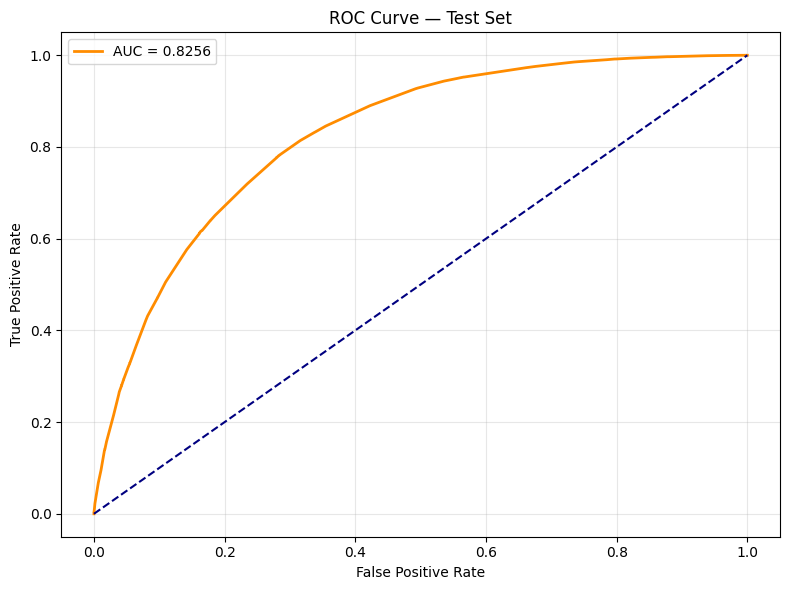

✓ Saved: plots/roc_curve_test.png


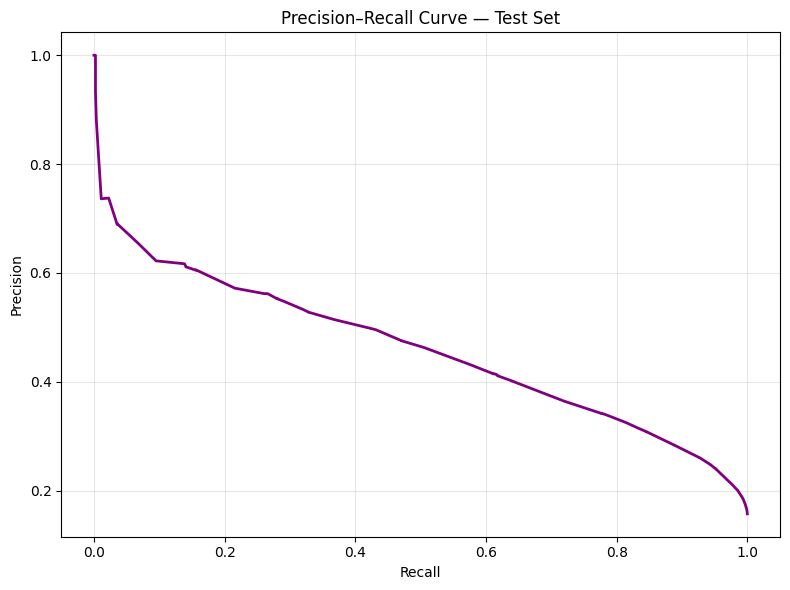

✓ Saved: plots/precision_recall_curve_test.png


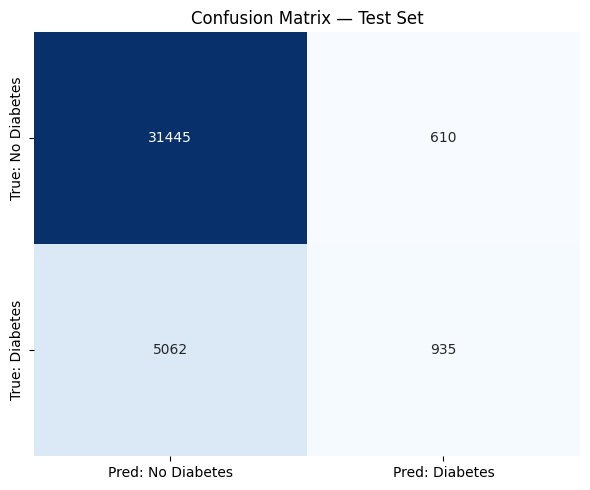

✓ Saved: plots/confusion_matrix_test.png


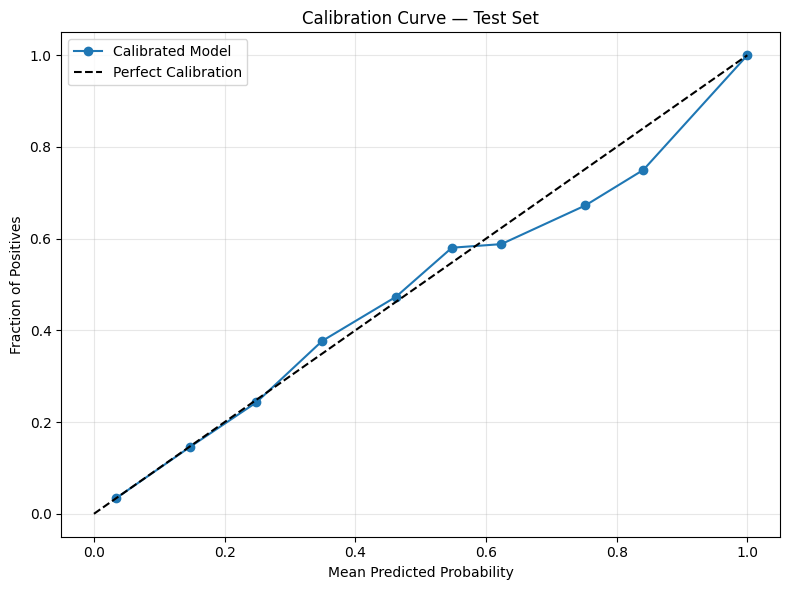

✓ Saved: plots/calibration_curve_test.png


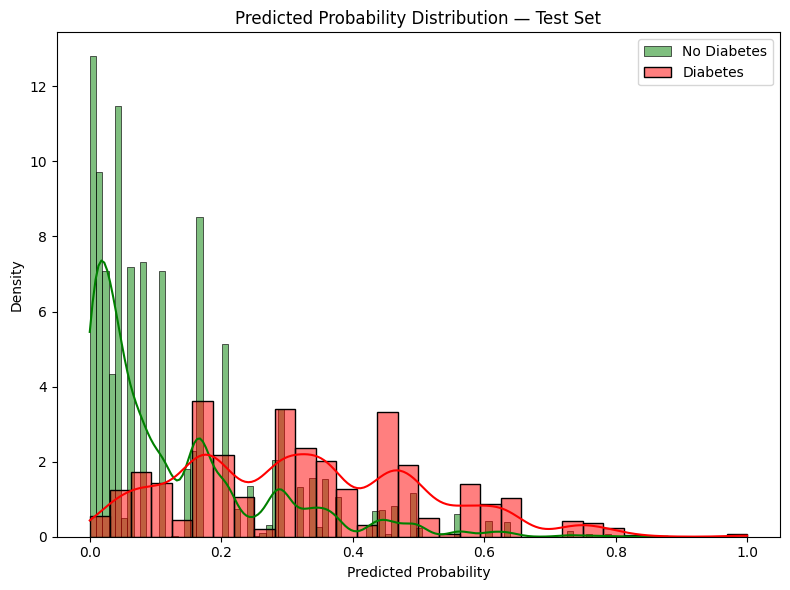

✓ Saved: plots/probability_distribution_test.png


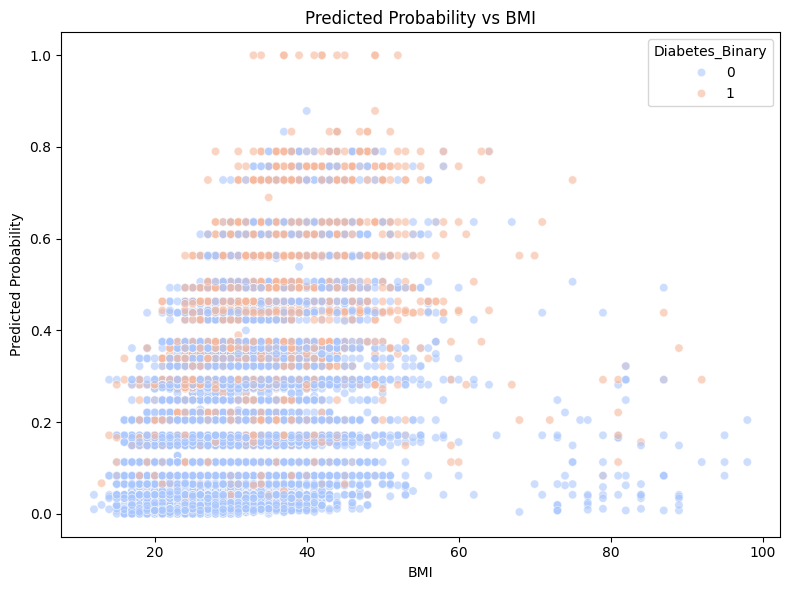

✓ Saved: plots/key_feature_probability_relationship.png


In [16]:
y_test_pred = calibrated_pipeline.predict(X_test)
y_test_proba = calibrated_pipeline.predict_proba(X_test)[:,1]

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1': f1_score(y_test, y_test_pred),
    'AUC': roc_auc_score(y_test, y_test_proba)
}
print("Test metrics:")
for k,v in test_metrics.items():
    print(f"{k}: {v:.4f}")

cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix:\n", cm)
print(classification_report(y_test, y_test_pred, target_names=['No Diabetes','Diabetes']))

# ============================================================
# STEP 13B — VISUALIZATIONS FOR TEST SET PERFORMANCE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

# Create directory for plots
os.makedirs("plots", exist_ok=True)

# ------------------------------------------------------------
# 1. ROC Curve
# ------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {test_metrics['AUC']:.4f}", linewidth=2, color='darkorange')
plt.plot([0,1], [0,1], linestyle="--", color="navy")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/roc_curve_test.png", dpi=300)
plt.show()

print("✓ Saved: plots/roc_curve_test.png")


# ------------------------------------------------------------
# 2. Precision–Recall Curve
# ------------------------------------------------------------
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Test Set")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/precision_recall_curve_test.png", dpi=300)
plt.show()

print("✓ Saved: plots/precision_recall_curve_test.png")


# ------------------------------------------------------------
# 3. Confusion Matrix Heatmap
# ------------------------------------------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Pred: No Diabetes', 'Pred: Diabetes'],
            yticklabels=['True: No Diabetes', 'True: Diabetes'])
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("plots/confusion_matrix_test.png", dpi=300)
plt.show()

print("✓ Saved: plots/confusion_matrix_test.png")


# ------------------------------------------------------------
# 4. Calibration Curve Plot
# ------------------------------------------------------------
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_test_proba, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(mean_predicted_value, fraction_of_positives, "o-", label="Calibrated Model")
plt.plot([0,1],[0,1], "k--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve — Test Set")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("plots/calibration_curve_test.png", dpi=300)
plt.show()

print("✓ Saved: plots/calibration_curve_test.png")


# ------------------------------------------------------------
# 5. Probability Distribution for Predictions
# ------------------------------------------------------------
plt.figure(figsize=(8,6))
sns.histplot(y_test_proba[y_test == 0], color='green', label='No Diabetes', kde=True, stat="density")
sns.histplot(y_test_proba[y_test == 1], color='red', label='Diabetes', kde=True, stat="density")
plt.title("Predicted Probability Distribution — Test Set")
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("plots/probability_distribution_test.png", dpi=300)
plt.show()

print("✓ Saved: plots/probability_distribution_test.png")


# ------------------------------------------------------------
# 6. Feature Contribution — Predicted Probability vs Key Feature
# ------------------------------------------------------------
key_feature = "BMI" if "BMI" in X_test.columns else X_test.columns[0]

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test[key_feature], y=y_test_proba, hue=y_test, palette='coolwarm', alpha=0.6)
plt.title(f"Predicted Probability vs {key_feature}")
plt.xlabel(key_feature)
plt.ylabel("Predicted Probability")
plt.tight_layout()
plt.savefig("plots/key_feature_probability_relationship.png", dpi=300)
plt.show()

print("✓ Saved: plots/key_feature_probability_relationship.png")




STEP 12 — SHAP Feature Importance

Saved shap_summary.png
Saved shap_bar.png


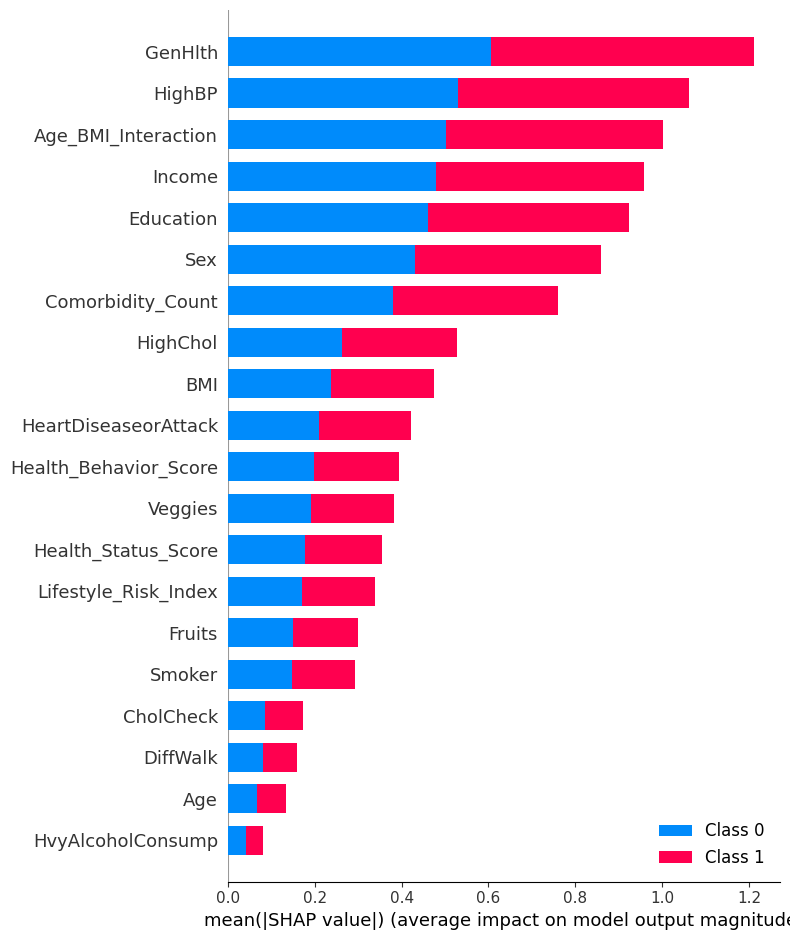

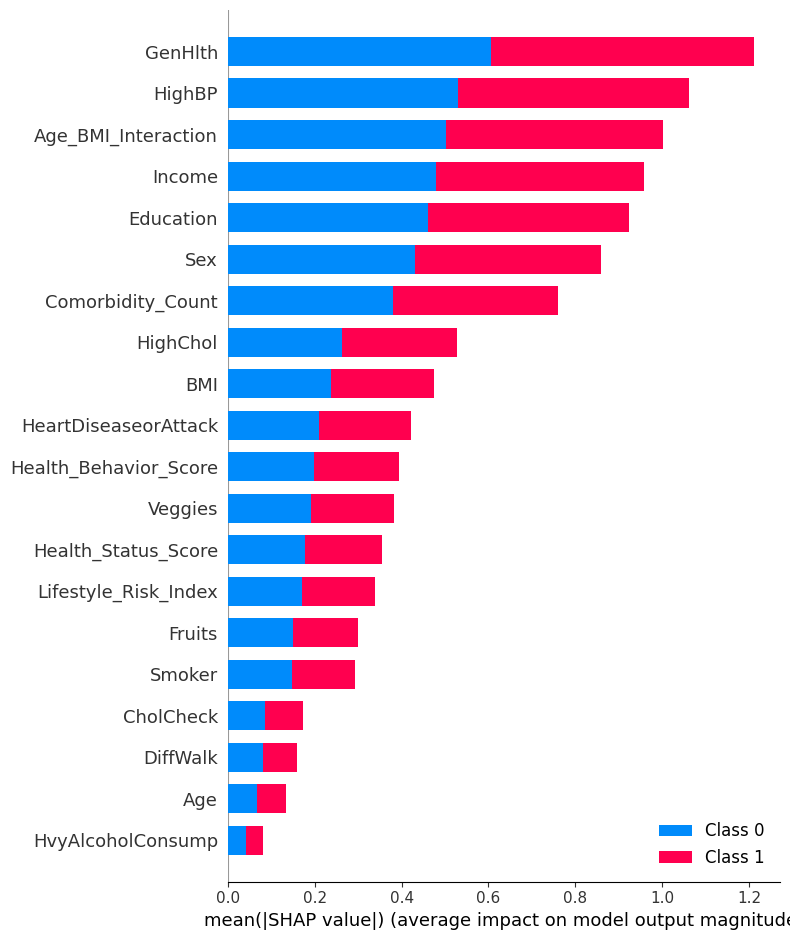

In [17]:
internal_model = best_pipeline.named_steps['model']
preprocessor = best_pipeline.named_steps['preprocess']

# Only run SHAP for tree-based internal models
if not isinstance(internal_model, (xgb.XGBClassifier, lgb.LGBMClassifier, RandomForestClassifier)):
    print("SHAP: best internal model is not tree-based; skipping.")
else:
    # Sample and ensure numeric
    sample_size = min(300, len(X_test))
    X_shap_raw = X_test.sample(sample_size, random_state=RANDOM_STATE).copy()
    # safety numeric conversion (should be unnecessary after cleaning, but safe)
    for col in X_shap_raw.columns:
        X_shap_raw[col] = pd.to_numeric(X_shap_raw[col], errors='coerce')
    X_shap_raw.dropna(inplace=True)

    if preprocessor == 'passthrough':
        X_shap = X_shap_raw
        feature_names = X_shap.columns
    else:
        X_shap = preprocessor.transform(X_shap_raw)
        # get_feature_names_out available for ColumnTransformer in sklearn >=1.0
        try:
            feature_names = preprocessor.get_feature_names_out()
        except Exception:
            feature_names = X_shap_raw.columns

    # Build SHAP explainer and values
    explainer = shap.TreeExplainer(internal_model)
    shap_values = explainer.shap_values(X_shap)

    # Summary (beeswarm)
    plt.figure(figsize=(10,8))
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
    print("Saved shap_summary.png")

    # Bar plot
    plt.figure(figsize=(10,6))
    shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type='bar', show=False, max_display=20)
    plt.tight_layout()
    plt.savefig("shap_bar.png", dpi=300, bbox_inches='tight')
    print("Saved shap_bar.png")


STEP13 - Saving the final calibrated pipeline

In [18]:
# 15) Save calibrated pipeline
os.makedirs("models", exist_ok=True)
joblib.dump(calibrated_pipeline, "models/lifestyle_calibrated_pipeline.joblib")
print("Saved calibrated pipeline to models/lifestyle_calibrated_pipeline.joblib")


Saved calibrated pipeline to models/lifestyle_calibrated_pipeline.joblib
